# 02 - Feature Engineering et Modélisation Baseline

**Projet** : Scoring de Crédit et Prévision de Défauts  
**Auteur** : Shafin Hamjah (Data Engineer)  
**Date** : Janvier 2026

---

## Objectifs de ce notebook

1. **Feature Engineering** : Créer de nouvelles variables prédictives
2. **Préparation des données** : Split temporel et encodage
3. **Modélisation Baseline** : Régression logistique avec SMOTE
4. **Évaluation** : Métriques et visualisations
5. **Analyse temporelle** : Étude préliminaire de la série des défauts

## 0. Configuration et imports

In [1]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix, f1_score,
    precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
import joblib

# Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Seed pour reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chemins
ROOT_DIR = Path('..')
DATA_PATH = ROOT_DIR / 'data' / 'processed' / 'credit_data_cleaned.parquet'
FIGURES_PATH = ROOT_DIR / 'outputs' / 'figures' / '02_modeling'
MODELS_PATH = ROOT_DIR / 'outputs' / 'models'

# Créer les dossiers si nécessaire
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("Configuration terminée ✓")
print(f"Fichier de données : {DATA_PATH}")

Configuration terminée ✓
Fichier de données : ..\data\processed\credit_data_cleaned.parquet


## 1. Chargement des données nettoyées

In [2]:
# Chargement des données prétraitées
df = pd.read_parquet(DATA_PATH)

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nPériode : {df['DATE_MONTH'].min()} à {df['DATE_MONTH'].max()}")

Dimensions : 130,000 lignes × 66 colonnes
Mémoire : 46.37 MB

Période : 2021-01-01 00:00:00 à 2025-12-01 00:00:00


In [3]:
# Rappel de la distribution de la cible
target_dist = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

print("Distribution TARGET :")
print(f"  0 (Non défaut) : {target_dist[0]:,} ({target_pct[0]:.2f}%)")
print(f"  1 (Défaut)     : {target_dist[1]:,} ({target_pct[1]:.2f}%)")
print(f"\n⚠️ Ratio de déséquilibre : 1:{target_dist[0]/target_dist[1]:.1f}")

Distribution TARGET :
  0 (Non défaut) : 105,820 (81.40%)
  1 (Défaut)     : 24,180 (18.60%)

⚠️ Ratio de déséquilibre : 1:4.4


In [4]:
# Aperçu des colonnes disponibles
print(f"Colonnes ({len(df.columns)}) :")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}", end="\t\t" if i % 3 != 0 else "\n")

Colonnes (66) :
 1. CLIENT_ID		 2. TARGET		 3. AGE
 4. SEX		 5. MARITAL_STATUS		 6. CHILDREN_COUNT
 7. EDUCATION_LEVEL		 8. EMPLOYMENT_TYPE		 9. SENIORITY_YEARS
10. IS_HOMEOWNER		11. HOUSING_TYPE		12. REGION
13. RESIDENCE_SINCE_YEARS		14. PHONE_VERIFIED		15. EMAIL_VERIFIED
16. HAS_CAR		17. NB_CREDIT_CARDS		18. HAS_PREVIOUS_DEFAULT
19. IS_FOREIGN_WORKER		20. CHANNEL		21. SEGMENT
22. DEVICE_OS		23. LOAN_AMOUNT		24. LOAN_TERM_MONTHS
25. INTEREST_RATE		26. INCOME_MONTHLY		27. EXPENSES_MONTHLY
28. MONTHLY_INSTALLMENT		29. DTI_RATIO		30. SAVINGS_BALANCE_M3
31. CHECKING_BALANCE_M3		32. SAVINGS_BALANCE_M2		33. CHECKING_BALANCE_M2
34. SAVINGS_BALANCE_M1		35. CHECKING_BALANCE_M1		36. AVG_BALANCE_3M
37. VAR_BALANCE_3M		38. NUM_LATE_PAYMENTS_12M		39. UTILIZATION_RATE
40. CREDIT_SCORE		41. NUM_OPEN_LOANS		42. TOTAL_CREDIT_LIMIT
43. LAST_WITHDRAWAL_AMOUNT		44. LAST_DEPOSIT_AMOUNT		45. POS_TXN_COUNT_30D
46. ATM_TXN_COUNT_30D		47. ONLINE_TXN_COUNT_30D		48. DAYS_SINCE_LAST_PAYMENT
49. INQUIRIES_6M		50.

---

## 2. Feature Engineering

Création de nouvelles variables pour améliorer le pouvoir prédictif du modèle.

### Catégories de features à créer :
- **Financières** : Ratios, capacités, marges
- **Comportementales** : Transactions, engagement digital
- **Stabilité** : Tendances des soldes, ancienneté
- **Risque** : Scores personnalisés, flags
- **Interactions** : Combinaisons de variables

### 2.1 Features financières

In [5]:
# Copie pour le feature engineering
df_fe = df.copy()
initial_cols = len(df_fe.columns)

print("Création des features financières...\n")

# Ratio épargne/revenu
df_fe['SAVINGS_TO_INCOME'] = df_fe['SAVINGS_BALANCE_M1'] / (df_fe['INCOME_MONTHLY'] + 1)

# Ratio compte courant/revenu  
df_fe['CHECKING_TO_INCOME'] = df_fe['CHECKING_BALANCE_M1'] / (df_fe['INCOME_MONTHLY'] + 1)

# Total des soldes par mois
df_fe['TOTAL_BALANCE_M1'] = df_fe['SAVINGS_BALANCE_M1'] + df_fe['CHECKING_BALANCE_M1']
df_fe['TOTAL_BALANCE_M2'] = df_fe['SAVINGS_BALANCE_M2'] + df_fe['CHECKING_BALANCE_M2']
df_fe['TOTAL_BALANCE_M3'] = df_fe['SAVINGS_BALANCE_M3'] + df_fe['CHECKING_BALANCE_M3']

# Moyenne des soldes totaux sur 3 mois
df_fe['AVG_TOTAL_BALANCE'] = (df_fe['TOTAL_BALANCE_M1'] + df_fe['TOTAL_BALANCE_M2'] + df_fe['TOTAL_BALANCE_M3']) / 3

# Ratio prêt/revenu annuel
df_fe['LOAN_TO_ANNUAL_INCOME'] = df_fe['LOAN_AMOUNT'] / (df_fe['INCOME_MONTHLY'] * 12 + 1)

# Capacité de remboursement = Revenu - Dépenses - Mensualité
df_fe['REPAYMENT_CAPACITY'] = df_fe['INCOME_MONTHLY'] - df_fe['EXPENSES_MONTHLY'] - df_fe['MONTHLY_INSTALLMENT']

# Ratio dépenses/revenu
df_fe['EXPENSE_RATIO'] = df_fe['EXPENSES_MONTHLY'] / (df_fe['INCOME_MONTHLY'] + 1)

# Marge financière mensuelle
df_fe['FINANCIAL_MARGIN'] = df_fe['INCOME_MONTHLY'] - df_fe['EXPENSES_MONTHLY']

# Indicateur de stress financier
df_fe['FINANCIAL_STRESS'] = ((df_fe['DTI_RATIO'] > 0.4) | (df_fe['EXPENSE_RATIO'] > 0.7)).astype('int8')

financial_features = [
    'SAVINGS_TO_INCOME', 'CHECKING_TO_INCOME', 'TOTAL_BALANCE_M1', 'TOTAL_BALANCE_M2',
    'TOTAL_BALANCE_M3', 'AVG_TOTAL_BALANCE', 'LOAN_TO_ANNUAL_INCOME', 
    'REPAYMENT_CAPACITY', 'EXPENSE_RATIO', 'FINANCIAL_MARGIN', 'FINANCIAL_STRESS'
]

print(f"✓ {len(financial_features)} features financières créées :")
for f in financial_features:
    print(f"  - {f}")

Création des features financières...

✓ 11 features financières créées :
  - SAVINGS_TO_INCOME
  - CHECKING_TO_INCOME
  - TOTAL_BALANCE_M1
  - TOTAL_BALANCE_M2
  - TOTAL_BALANCE_M3
  - AVG_TOTAL_BALANCE
  - LOAN_TO_ANNUAL_INCOME
  - REPAYMENT_CAPACITY
  - EXPENSE_RATIO
  - FINANCIAL_MARGIN
  - FINANCIAL_STRESS


### 2.2 Features comportementales

In [6]:
print("Création des features comportementales...\n")

# Total des transactions sur 30 jours
df_fe['TOTAL_TXN_30D'] = df_fe['POS_TXN_COUNT_30D'] + df_fe['ATM_TXN_COUNT_30D'] + df_fe['ONLINE_TXN_COUNT_30D']

# Ratio transactions en ligne
df_fe['ONLINE_TXN_RATIO'] = df_fe['ONLINE_TXN_COUNT_30D'] / (df_fe['TOTAL_TXN_30D'] + 1)

# Total connexions digitales
df_fe['TOTAL_DIGITAL_LOGINS'] = df_fe['MOBILE_LOGINS_30D'] + df_fe['WEB_LOGINS_30D']

# Préférence mobile vs web
df_fe['MOBILE_PREFERENCE'] = df_fe['MOBILE_LOGINS_30D'] / (df_fe['TOTAL_DIGITAL_LOGINS'] + 1)

# Score d'engagement digital
df_fe['DIGITAL_ENGAGEMENT'] = df_fe['TOTAL_DIGITAL_LOGINS'] + df_fe['ONLINE_TXN_COUNT_30D'] * 2

# Client actif en agence
df_fe['IS_BRANCH_ACTIVE'] = (df_fe['BRANCH_VISITS_6M'] >= 2).astype('int8')

# Ratio retrait/dépôt
df_fe['WITHDRAWAL_DEPOSIT_RATIO'] = df_fe['LAST_WITHDRAWAL_AMOUNT'] / (df_fe['LAST_DEPOSIT_AMOUNT'] + 1)

behavioral_features = [
    'TOTAL_TXN_30D', 'ONLINE_TXN_RATIO', 'TOTAL_DIGITAL_LOGINS',
    'MOBILE_PREFERENCE', 'DIGITAL_ENGAGEMENT', 'IS_BRANCH_ACTIVE', 'WITHDRAWAL_DEPOSIT_RATIO'
]

print(f"✓ {len(behavioral_features)} features comportementales créées :")
for f in behavioral_features:
    print(f"  - {f}")

Création des features comportementales...

✓ 7 features comportementales créées :
  - TOTAL_TXN_30D
  - ONLINE_TXN_RATIO
  - TOTAL_DIGITAL_LOGINS
  - MOBILE_PREFERENCE
  - DIGITAL_ENGAGEMENT
  - IS_BRANCH_ACTIVE
  - WITHDRAWAL_DEPOSIT_RATIO


### 2.3 Features de stabilité

In [7]:
print("Création des features de stabilité...\n")

# Stabilité des soldes épargne (écart-type sur 3 mois)
savings_cols = ['SAVINGS_BALANCE_M1', 'SAVINGS_BALANCE_M2', 'SAVINGS_BALANCE_M3']
df_fe['SAVINGS_STABILITY'] = df_fe[savings_cols].std(axis=1)

# Stabilité des soldes compte courant
checking_cols = ['CHECKING_BALANCE_M1', 'CHECKING_BALANCE_M2', 'CHECKING_BALANCE_M3']
df_fe['CHECKING_STABILITY'] = df_fe[checking_cols].std(axis=1)

# Coefficient de variation des soldes
df_fe['BALANCE_CV'] = df_fe['SAVINGS_STABILITY'] / (df_fe[savings_cols].mean(axis=1).abs() + 1)

# Tendance épargne (M1 - M3 : positif = croissant)
df_fe['SAVINGS_TREND'] = df_fe['SAVINGS_BALANCE_M1'] - df_fe['SAVINGS_BALANCE_M3']
df_fe['SAVINGS_TREND_RATIO'] = df_fe['SAVINGS_TREND'] / (df_fe['SAVINGS_BALANCE_M3'].abs() + 1)

# Tendance compte courant
df_fe['CHECKING_TREND'] = df_fe['CHECKING_BALANCE_M1'] - df_fe['CHECKING_BALANCE_M3']
df_fe['CHECKING_TREND_RATIO'] = df_fe['CHECKING_TREND'] / (df_fe['CHECKING_BALANCE_M3'].abs() + 1)

# Stabilité emploi (ancienneté >= 2 ans)
df_fe['EMPLOYMENT_STABILITY'] = (df_fe['SENIORITY_YEARS'] >= 2).astype('int8')

# Stabilité résidence
df_fe['RESIDENCE_STABILITY'] = (df_fe['RESIDENCE_SINCE_YEARS'] >= 2).astype('int8')

stability_features = [
    'SAVINGS_STABILITY', 'CHECKING_STABILITY', 'BALANCE_CV',
    'SAVINGS_TREND', 'SAVINGS_TREND_RATIO', 'CHECKING_TREND', 'CHECKING_TREND_RATIO',
    'EMPLOYMENT_STABILITY', 'RESIDENCE_STABILITY'
]

print(f"✓ {len(stability_features)} features de stabilité créées :")
for f in stability_features:
    print(f"  - {f}")

Création des features de stabilité...

✓ 9 features de stabilité créées :
  - SAVINGS_STABILITY
  - CHECKING_STABILITY
  - BALANCE_CV
  - SAVINGS_TREND
  - SAVINGS_TREND_RATIO
  - CHECKING_TREND
  - CHECKING_TREND_RATIO
  - EMPLOYMENT_STABILITY
  - RESIDENCE_STABILITY


### 2.4 Features de risque

In [8]:
print("Création des features de risque...\n")

# Score de risque personnalisé (pondération des facteurs de risque)
df_fe['RISK_SCORE_CUSTOM'] = (
    df_fe['NUM_LATE_PAYMENTS_12M'] * 10 +
    df_fe['HAS_PREVIOUS_DEFAULT'] * 20 +
    df_fe['INQUIRIES_6M'] * 5 +
    (df_fe['UTILIZATION_RATE'] > 0.7).astype(int) * 15 +
    (df_fe['DTI_RATIO'] > 0.5).astype(int) * 10
)

# Credit score normalisé (entre 0 et 1)
df_fe['CREDIT_SCORE_NORM'] = (
    (df_fe['CREDIT_SCORE'] - df_fe['CREDIT_SCORE'].min()) / 
    (df_fe['CREDIT_SCORE'].max() - df_fe['CREDIT_SCORE'].min())
)

# Catégorie de credit score
df_fe['CREDIT_SCORE_CAT'] = pd.cut(
    df_fe['CREDIT_SCORE'],
    bins=[0, 500, 600, 700, 800, 1000],
    labels=['very_poor', 'poor', 'fair', 'good', 'excellent']
)

# Ratio prêts ouverts / limite crédit
df_fe['LOAN_UTILIZATION'] = df_fe['NUM_OPEN_LOANS'] / (df_fe['TOTAL_CREDIT_LIMIT'] / 10000 + 1)

# Flag client à haut risque
df_fe['HIGH_RISK_FLAG'] = (
    (df_fe['NUM_LATE_PAYMENTS_12M'] >= 2) |
    (df_fe['HAS_PREVIOUS_DEFAULT'] == 1) |
    (df_fe['CREDIT_SCORE'] < 550) |
    (df_fe['DTI_RATIO'] > 0.6)
).astype('int8')

# Flag nouveau client
df_fe['IS_NEW_CLIENT'] = (
    (df_fe['SENIORITY_YEARS'] < 1) &
    (df_fe['NUM_OPEN_LOANS'] == 0)
).astype('int8')

risk_features = [
    'RISK_SCORE_CUSTOM', 'CREDIT_SCORE_NORM', 'CREDIT_SCORE_CAT',
    'LOAN_UTILIZATION', 'HIGH_RISK_FLAG', 'IS_NEW_CLIENT'
]

print(f"✓ {len(risk_features)} features de risque créées :")
for f in risk_features:
    print(f"  - {f}")

Création des features de risque...

✓ 6 features de risque créées :
  - RISK_SCORE_CUSTOM
  - CREDIT_SCORE_NORM
  - CREDIT_SCORE_CAT
  - LOAN_UTILIZATION
  - HIGH_RISK_FLAG
  - IS_NEW_CLIENT


### 2.5 Features d'interaction

In [9]:
print("Création des features d'interaction...\n")

# Age × Ancienneté emploi
df_fe['AGE_SENIORITY'] = df_fe['AGE'] * df_fe['SENIORITY_YEARS']

# Revenu × Score crédit normalisé
df_fe['INCOME_CREDIT_SCORE'] = df_fe['INCOME_MONTHLY'] * df_fe['CREDIT_SCORE_NORM']

# DTI × Taux d'utilisation crédit
df_fe['DTI_UTILIZATION'] = df_fe['DTI_RATIO'] * df_fe['UTILIZATION_RATE']

# Coût total du prêt (montant × taux)
df_fe['LOAN_INTEREST_COST'] = df_fe['LOAN_AMOUNT'] * df_fe['INTEREST_RATE']

# Balance moyenne par mois de prêt
df_fe['BALANCE_LOAN_TERM'] = df_fe['AVG_TOTAL_BALANCE'] / (df_fe['LOAN_TERM_MONTHS'] + 1)

interaction_features = [
    'AGE_SENIORITY', 'INCOME_CREDIT_SCORE', 'DTI_UTILIZATION',
    'LOAN_INTEREST_COST', 'BALANCE_LOAN_TERM'
]

print(f"✓ {len(interaction_features)} features d'interaction créées :")
for f in interaction_features:
    print(f"  - {f}")

Création des features d'interaction...

✓ 5 features d'interaction créées :
  - AGE_SENIORITY
  - INCOME_CREDIT_SCORE
  - DTI_UTILIZATION
  - LOAN_INTEREST_COST
  - BALANCE_LOAN_TERM


### 2.6 Nettoyage et résumé du Feature Engineering

In [10]:
# Remplacer les valeurs infinies par NaN
df_fe = df_fe.replace([np.inf, -np.inf], np.nan)

# Remplir les NaN créés par les divisions par la médiane
numeric_cols = df_fe.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_fe[col].isnull().any():
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

# Résumé
new_cols = len(df_fe.columns) - initial_cols
all_new_features = financial_features + behavioral_features + stability_features + risk_features + interaction_features

print("=" * 50)
print("RÉSUMÉ DU FEATURE ENGINEERING")
print("=" * 50)
print(f"Colonnes initiales : {initial_cols}")
print(f"Nouvelles features : {new_cols}")
print(f"Colonnes finales   : {len(df_fe.columns)}")
print(f"\nRépartition :")
print(f"  - Financières      : {len(financial_features)}")
print(f"  - Comportementales : {len(behavioral_features)}")
print(f"  - Stabilité        : {len(stability_features)}")
print(f"  - Risque           : {len(risk_features)}")
print(f"  - Interactions     : {len(interaction_features)}")

RÉSUMÉ DU FEATURE ENGINEERING
Colonnes initiales : 66
Nouvelles features : 38
Colonnes finales   : 104

Répartition :
  - Financières      : 11
  - Comportementales : 7
  - Stabilité        : 9
  - Risque           : 6
  - Interactions     : 5


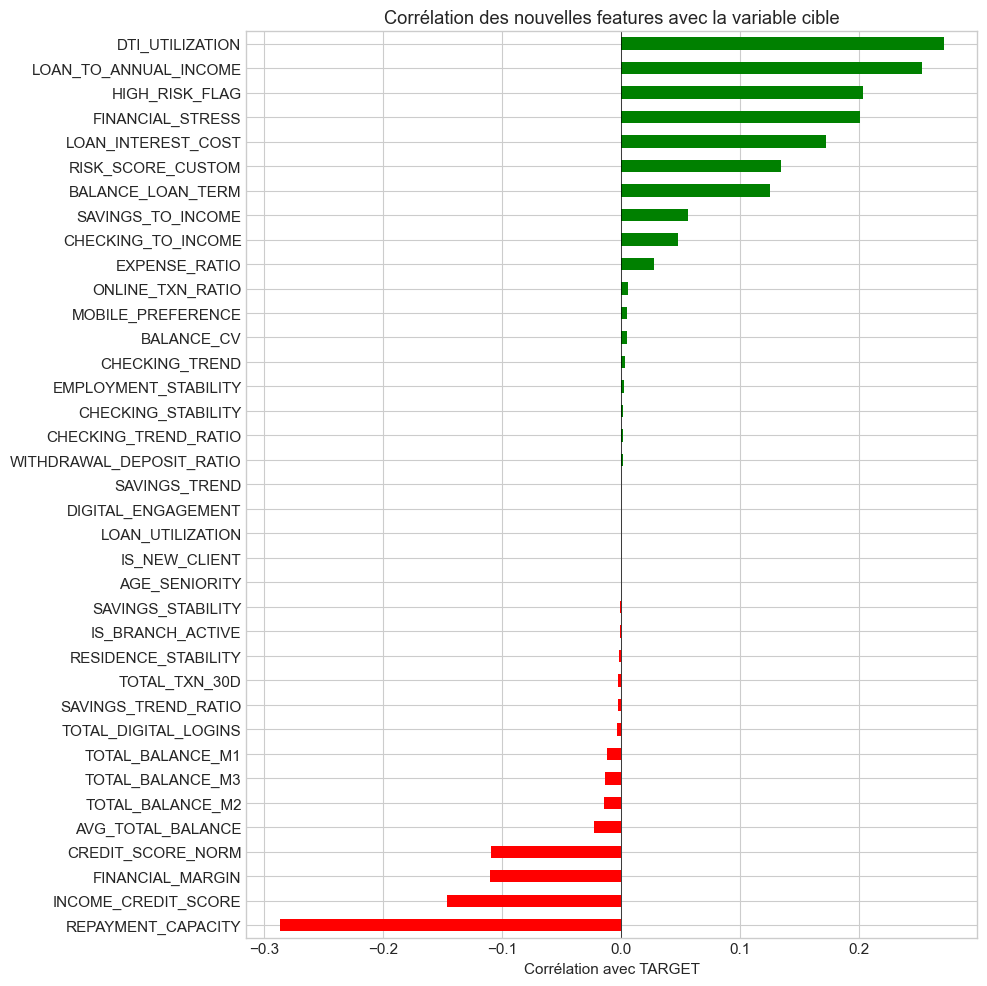

In [11]:
# Visualisation : Corrélation des nouvelles features avec TARGET
new_features_numeric = [f for f in all_new_features if f != 'CREDIT_SCORE_CAT']
correlations = df_fe[new_features_numeric + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red' if x < 0 else 'green' for x in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Corrélation avec TARGET')
ax.set_title('Corrélation des nouvelles features avec la variable cible')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'correlation_nouvelles_features.png', dpi=150)
plt.show()

---

## 3. Préparation pour la modélisation

### 3.1 Split temporel

⚠️ **Important** : Pour éviter le data leakage, on utilise un split temporel basé sur `DATE_MONTH` et non un split aléatoire.

In [12]:
# Colonnes à exclure de la modélisation
exclude_cols = [
    'CLIENT_ID', 'TARGET', 'DATE_MONTH', 'DEFAULTS_ORIGINATION',
    'CREDIT_SCORE_CAT'  # Variable catégorielle (sera encodée séparément si besoin)
]

# Variables catégorielles à encoder
cat_cols = df_fe.select_dtypes(include=['category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in exclude_cols]

print(f"Variables catégorielles à encoder ({len(cat_cols)}) :")
print(cat_cols)

Variables catégorielles à encoder (11) :
['SEX', 'MARITAL_STATUS', 'EDUCATION_LEVEL', 'EMPLOYMENT_TYPE', 'HOUSING_TYPE', 'REGION', 'CHANNEL', 'SEGMENT', 'DEVICE_OS', 'PAYMENT_METHOD', 'RISK_BAND_INTERNAL']


In [13]:
# Encodage des variables catégorielles (Label Encoding)
df_encoded = df_fe.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"  {col} : {len(le.classes_)} modalités")

print(f"\n✓ {len(cat_cols)} variables encodées")

  SEX : 2 modalités
  MARITAL_STATUS : 4 modalités
  EDUCATION_LEVEL : 5 modalités
  EMPLOYMENT_TYPE : 6 modalités
  HOUSING_TYPE : 3 modalités
  REGION : 12 modalités
  CHANNEL : 4 modalités
  SEGMENT : 5 modalités
  DEVICE_OS : 3 modalités
  PAYMENT_METHOD : 4 modalités
  RISK_BAND_INTERNAL : 5 modalités

✓ 11 variables encodées


In [14]:
# Sélection des features et de la cible
feature_cols = [c for c in df_encoded.columns if c not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['TARGET']

print(f"Features : {X.shape[1]}")
print(f"Observations : {X.shape[0]:,}")

Features : 99
Observations : 130,000


In [15]:
# Split temporel : Train avant 2025-01, Test à partir de 2025-01
split_date = '2025-01-01'

train_mask = df_fe['DATE_MONTH'] < split_date
test_mask = df_fe['DATE_MONTH'] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print("SPLIT TEMPOREL")
print("=" * 40)
print(f"Date de coupure : {split_date}")
print(f"\nTrain : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Période : avant {split_date}")
print(f"  - Taux de défaut : {y_train.mean()*100:.2f}%")
print(f"\nTest : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Période : {split_date} et après")
print(f"  - Taux de défaut : {y_test.mean()*100:.2f}%")

SPLIT TEMPOREL
Date de coupure : 2025-01-01

Train : 98,700 (75.9%)
  - Période : avant 2025-01-01
  - Taux de défaut : 18.69%

Test : 31,300 (24.1%)
  - Période : 2025-01-01 et après
  - Taux de défaut : 18.32%


### 3.2 Standardisation

In [16]:
# Standardisation des features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Standardisation effectuée")
print(f"  Train : moyenne ≈ 0, écart-type ≈ 1")

✓ Standardisation effectuée
  Train : moyenne ≈ 0, écart-type ≈ 1


### 3.3 Rééquilibrage avec SMOTE

In [17]:
# Application de SMOTE pour gérer le déséquilibre des classes
print("Application de SMOTE...")
print(f"\nAvant SMOTE :")
print(f"  - Total : {len(y_train):,}")
print(f"  - Classe 0 : {(y_train == 0).sum():,}")
print(f"  - Classe 1 : {(y_train == 1).sum():,}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAprès SMOTE :")
print(f"  - Total : {len(y_train_resampled):,}")
print(f"  - Classe 0 : {(y_train_resampled == 0).sum():,}")
print(f"  - Classe 1 : {(y_train_resampled == 1).sum():,}")

Application de SMOTE...

Avant SMOTE :
  - Total : 98,700
  - Classe 0 : 80,254
  - Classe 1 : 18,446

Après SMOTE :
  - Total : 160,508
  - Classe 0 : 80,254
  - Classe 1 : 80,254


---

## 4. Modélisation : Régression Logistique (Baseline)

On commence par un modèle simple et interprétable pour établir une baseline.

In [18]:
# Entraînement du modèle
print("Entraînement de la régression logistique...")

model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs'
)

model.fit(X_train_resampled, y_train_resampled)

print("✓ Modèle entraîné")

Entraînement de la régression logistique...
✓ Modèle entraîné


In [19]:
# Prédictions sur le jeu de test
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"Prédictions effectuées sur {len(y_test):,} observations")

Prédictions effectuées sur 31,300 observations


### 4.1 Métriques de performance

In [20]:
# Calcul des métriques
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
}

print("=" * 50)
print("RÉSULTATS SUR LE JEU DE TEST")
print("=" * 50)
for metric, value in metrics.items():
    highlight = "⭐" if metric == 'AUC-ROC' else " "
    print(f"{highlight} {metric:12} : {value:.4f}")
print("=" * 50)

RÉSULTATS SUR LE JEU DE TEST
  Accuracy     : 0.6989
  Precision    : 0.3215
  Recall       : 0.5797
  F1-Score     : 0.4136
⭐ AUC-ROC      : 0.7105


In [21]:
# Rapport de classification détaillé
print("\nRAPPORT DE CLASSIFICATION")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Non défaut', 'Défaut']))


RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

  Non défaut       0.89      0.73      0.80     25566
      Défaut       0.32      0.58      0.41      5734

    accuracy                           0.70     31300
   macro avg       0.60      0.65      0.61     31300
weighted avg       0.78      0.70      0.73     31300



In [22]:
# Validation croisée sur le jeu d'entraînement
print("Validation croisée (5-fold) sur le train...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print(f"\nAUC-ROC CV : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"Scores par fold : {[f'{s:.4f}' for s in cv_scores]}")

Validation croisée (5-fold) sur le train...

AUC-ROC CV : 0.7170 (+/- 0.0107)
Scores par fold : ['0.7157', '0.7155', '0.7167', '0.7104', '0.7268']


### 4.2 Visualisations des performances

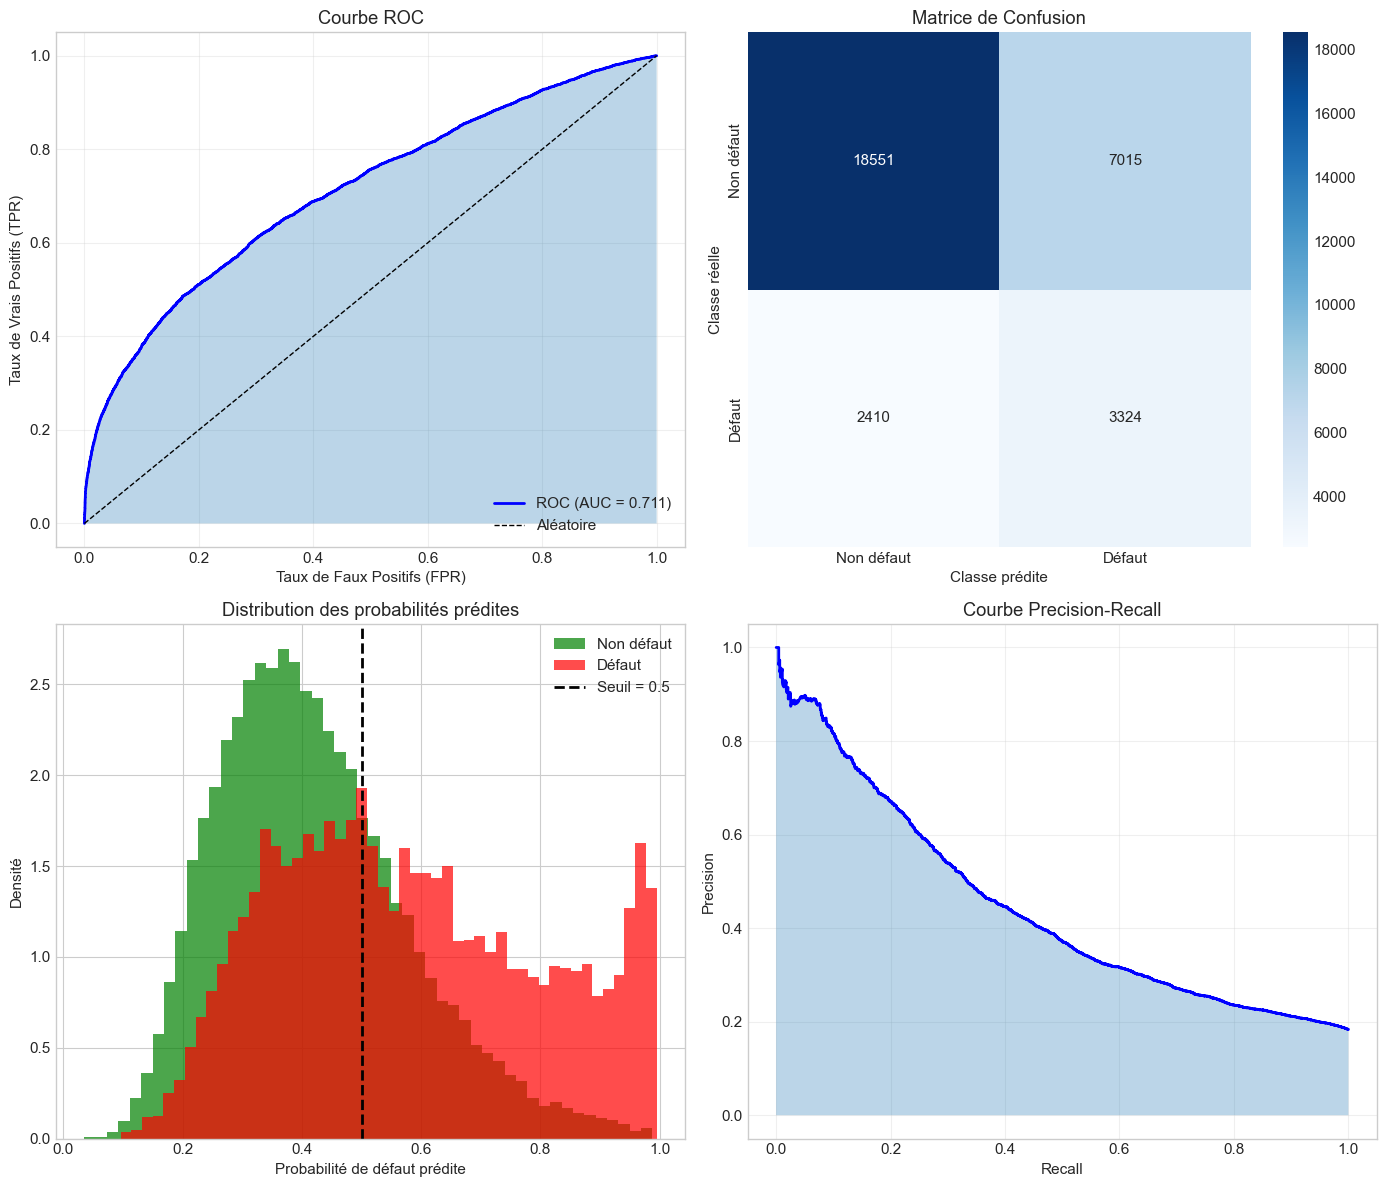

In [23]:
# Figure avec 4 graphiques
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {metrics["AUC-ROC"]:.3f})')
axes[0, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire')
axes[0, 0].fill_between(fpr, tpr, alpha=0.3)
axes[0, 0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0, 0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0, 0].set_title('Courbe ROC')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Non défaut', 'Défaut'],
            yticklabels=['Non défaut', 'Défaut'])
axes[0, 1].set_xlabel('Classe prédite')
axes[0, 1].set_ylabel('Classe réelle')
axes[0, 1].set_title('Matrice de Confusion')

# 3. Distribution des probabilités prédites
axes[1, 0].hist(y_pred_proba[y_test == 0], bins=50, alpha=0.7, label='Non défaut', color='green', density=True)
axes[1, 0].hist(y_pred_proba[y_test == 1], bins=50, alpha=0.7, label='Défaut', color='red', density=True)
axes[1, 0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Seuil = 0.5')
axes[1, 0].set_xlabel('Probabilité de défaut prédite')
axes[1, 0].set_ylabel('Densité')
axes[1, 0].set_title('Distribution des probabilités prédites')
axes[1, 0].legend()

# 4. Courbe Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1, 1].plot(recall, precision, 'b-', linewidth=2)
axes[1, 1].fill_between(recall, precision, alpha=0.3)
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Courbe Precision-Recall')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'performance_modele_baseline.png', dpi=150)
plt.show()

### 4.3 Importance des features

In [24]:
# Importance des features (valeur absolue des coefficients)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_[0],
    'importance': np.abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print("TOP 15 FEATURES LES PLUS IMPORTANTES")
print("=" * 50)
for i, row in feature_importance.head(15).iterrows():
    sign = "+" if row['coefficient'] > 0 else "-"
    print(f"{sign} {row['feature']:35} : {row['importance']:.4f}")

TOP 15 FEATURES LES PLUS IMPORTANTES
+ DTI_RATIO                           : 0.4272
+ INSTALLMENT_TO_INCOME               : 0.4272
- VAR_BALANCE_3M                      : 0.2198
- CREDIT_SCORE_NORM                   : 0.1724
- CREDIT_SCORE                        : 0.1724
+ CHECKING_STABILITY                  : 0.1286
+ HAS_PREVIOUS_DEFAULT                : 0.1165
+ LOAN_AMOUNT                         : 0.1100
- INSURANCE_TAKEN                     : 0.1082
+ PHONE_VERIFIED                      : 0.0890
+ ONLINE_TXN_RATIO                    : 0.0863
+ MOBILE_PREFERENCE                   : 0.0843
- AGE_SENIORITY                       : 0.0796
- LOAN_TO_ANNUAL_INCOME               : 0.0781
- WITHDRAWAL_DEPOSIT_RATIO            : 0.0744


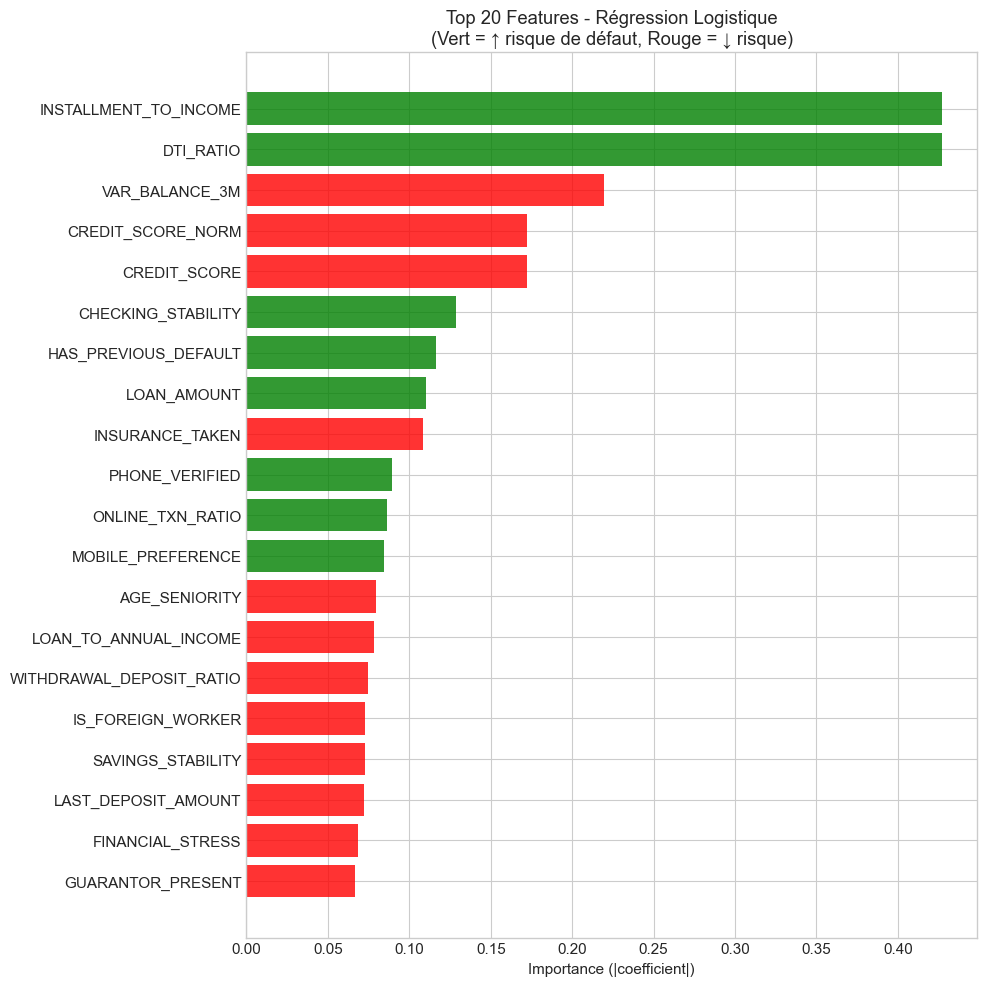

In [25]:
# Visualisation Top 20
top_20 = feature_importance.head(20).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red' if c < 0 else 'green' for c in top_20['coefficient']]
ax.barh(top_20['feature'], top_20['importance'], color=colors, alpha=0.8)
ax.set_xlabel('Importance (|coefficient|)')
ax.set_title('Top 20 Features - Régression Logistique\n(Vert = ↑ risque de défaut, Rouge = ↓ risque)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'importance_features_baseline.png', dpi=150)
plt.show()

---

## 5. Analyse temporelle préliminaire

Étude de la série `DEFAULTS_ORIGINATION` pour préparer la modélisation SARIMA en Phase 2.

In [26]:
# Agrégation mensuelle des défauts
monthly_data = df_fe.groupby('DATE_MONTH').agg({
    'TARGET': ['count', 'sum', 'mean'],
    'DEFAULTS_ORIGINATION': 'first'
}).reset_index()

monthly_data.columns = ['DATE_MONTH', 'nb_dossiers', 'nb_defauts', 'taux_defaut', 'defaults_origination']
monthly_data['taux_defaut'] *= 100

print(f"Période : {monthly_data['DATE_MONTH'].min()} à {monthly_data['DATE_MONTH'].max()}")
print(f"Nombre de mois : {len(monthly_data)}")

Période : 2021-01-01 00:00:00 à 2025-12-01 00:00:00
Nombre de mois : 60


In [27]:
# Statistiques descriptives de DEFAULTS_ORIGINATION
print("\nStatistiques DEFAULTS_ORIGINATION :")
print(f"  Moyenne     : {monthly_data['defaults_origination'].mean():.1f}")
print(f"  Écart-type  : {monthly_data['defaults_origination'].std():.1f}")
print(f"  Minimum     : {monthly_data['defaults_origination'].min()}")
print(f"  Maximum     : {monthly_data['defaults_origination'].max()}")
print(f"  Médiane     : {monthly_data['defaults_origination'].median():.1f}")


Statistiques DEFAULTS_ORIGINATION :
  Moyenne     : 403.0
  Écart-type  : 98.3
  Minimum     : 226
  Maximum     : 653
  Médiane     : 405.0


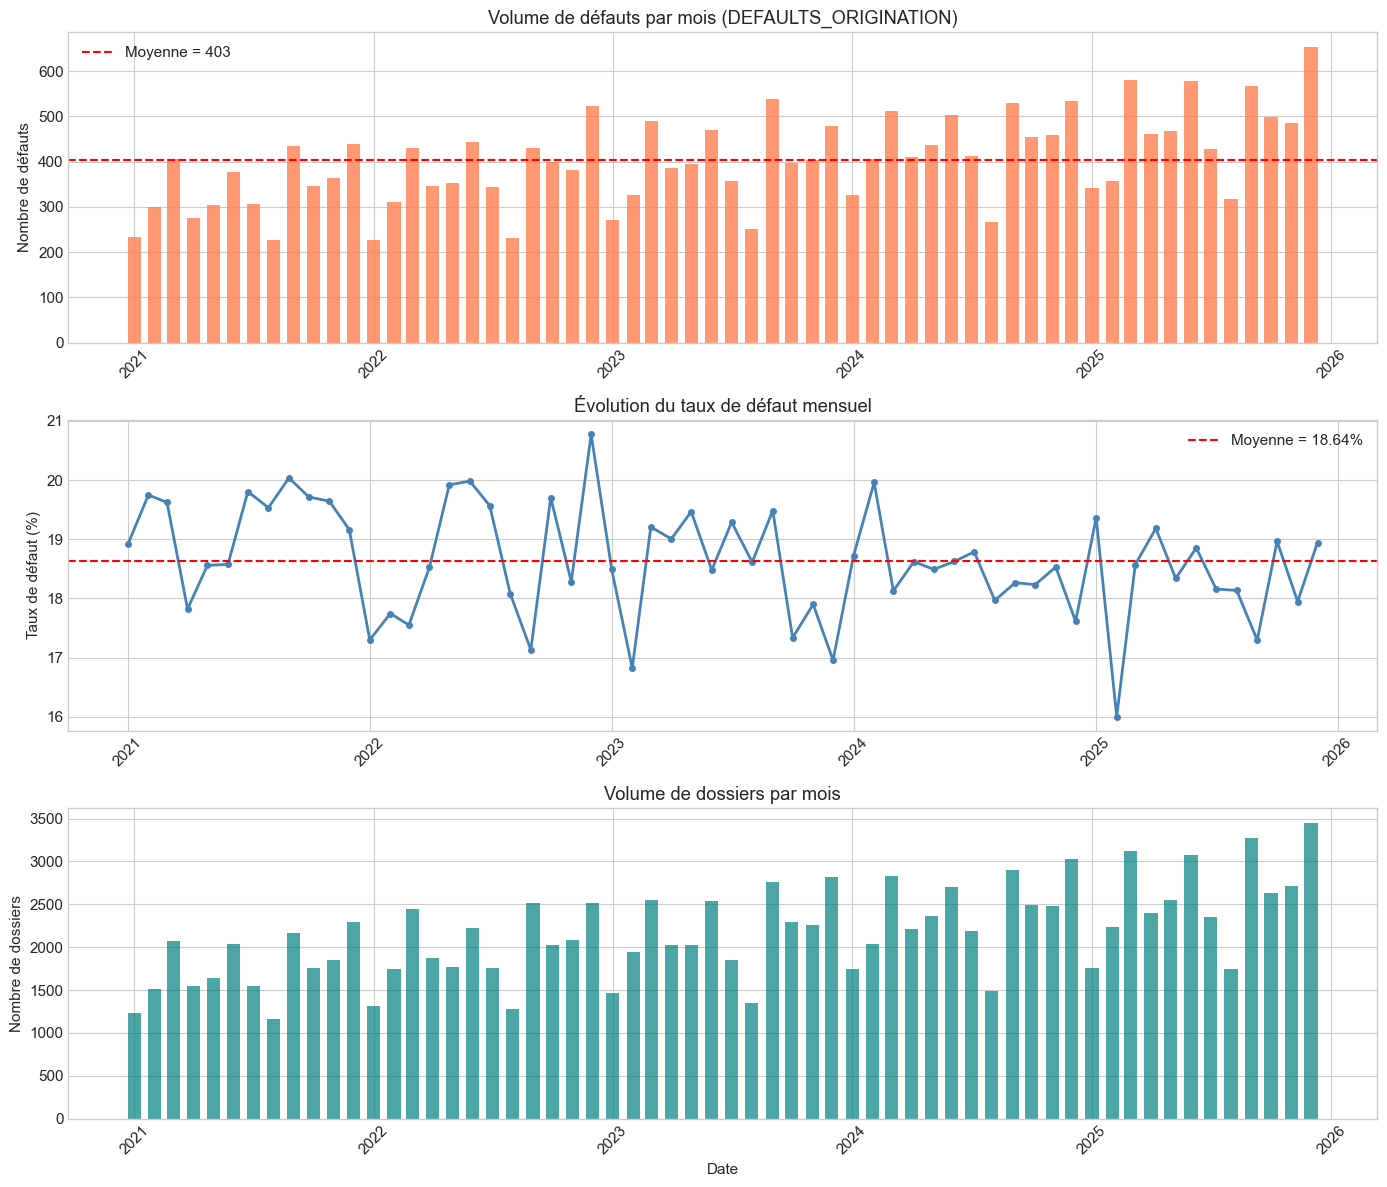

In [28]:
# Visualisation de la série temporelle
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Volume de défauts par mois
axes[0].bar(monthly_data['DATE_MONTH'], monthly_data['defaults_origination'], 
            color='coral', alpha=0.8, width=20)
axes[0].axhline(monthly_data['defaults_origination'].mean(), color='red', 
                linestyle='--', label=f"Moyenne = {monthly_data['defaults_origination'].mean():.0f}")
axes[0].set_ylabel('Nombre de défauts')
axes[0].set_title('Volume de défauts par mois (DEFAULTS_ORIGINATION)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 2. Taux de défaut mensuel
axes[1].plot(monthly_data['DATE_MONTH'], monthly_data['taux_defaut'], 
             marker='o', color='steelblue', linewidth=2, markersize=4)
axes[1].axhline(monthly_data['taux_defaut'].mean(), color='red', 
                linestyle='--', label=f"Moyenne = {monthly_data['taux_defaut'].mean():.2f}%")
axes[1].set_ylabel('Taux de défaut (%)')
axes[1].set_title('Évolution du taux de défaut mensuel')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# 3. Volume de dossiers par mois
axes[2].bar(monthly_data['DATE_MONTH'], monthly_data['nb_dossiers'], 
            color='teal', alpha=0.7, width=20)
axes[2].set_ylabel('Nombre de dossiers')
axes[2].set_xlabel('Date')
axes[2].set_title('Volume de dossiers par mois')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'serie_temporelle_defauts.png', dpi=150)
plt.show()

In [29]:
# Analyse de tendance
monthly_data['month_num'] = range(len(monthly_data))
correlation = monthly_data['month_num'].corr(monthly_data['defaults_origination'])

if correlation > 0.3:
    trend = "CROISSANTE 📈"
elif correlation < -0.3:
    trend = "DÉCROISSANTE 📉"
else:
    trend = "STABLE ➡️"

print("\nANALYSE DE TENDANCE")
print("=" * 40)
print(f"Corrélation temps/défauts : {correlation:.3f}")
print(f"Tendance : {trend}")


ANALYSE DE TENDANCE
Corrélation temps/défauts : 0.583
Tendance : CROISSANTE 📈


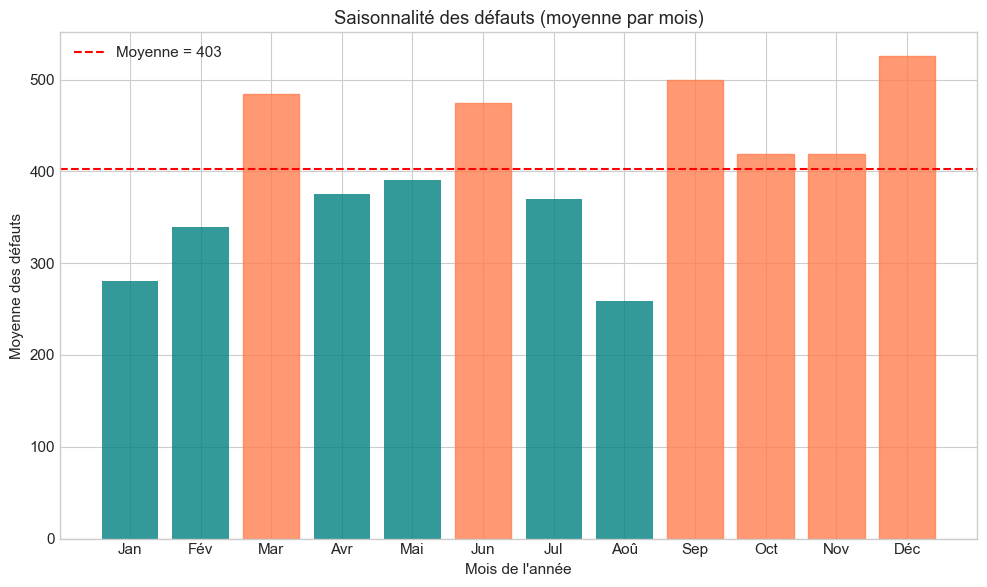


Mois avec le plus de défauts :
  Déc : 525 défauts en moyenne
  Sep : 500 défauts en moyenne
  Mar : 484 défauts en moyenne


In [30]:
# Analyse de saisonnalité
monthly_data['month_of_year'] = pd.to_datetime(monthly_data['DATE_MONTH']).dt.month
seasonality = monthly_data.groupby('month_of_year')['defaults_origination'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(seasonality.index, seasonality.values, color='teal', alpha=0.8)
ax.axhline(seasonality.mean(), color='red', linestyle='--', 
           label=f'Moyenne = {seasonality.mean():.0f}')

# Colorer les mois au-dessus de la moyenne
for i, bar in enumerate(bars):
    if seasonality.values[i] > seasonality.mean():
        bar.set_color('coral')

ax.set_xlabel('Mois de l\'année')
ax.set_ylabel('Moyenne des défauts')
ax.set_title('Saisonnalité des défauts (moyenne par mois)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
                    'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'saisonnalite_defauts.png', dpi=150)
plt.show()

print("\nMois avec le plus de défauts :")
top_months = seasonality.sort_values(ascending=False).head(3)
for month, value in top_months.items():
    month_name = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
                  'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'][month-1]
    print(f"  {month_name} : {value:.0f} défauts en moyenne")

---

## 6. Sauvegarde des résultats

In [31]:
# Sauvegarder les données avec les nouvelles features
features_path = ROOT_DIR / 'data' / 'processed' / 'features_engineered.parquet'
df_fe.to_parquet(features_path, index=False)
print(f"✓ Données avec features : {features_path}")

# Sauvegarder le modèle
model_path = MODELS_PATH / 'logistic_regression_baseline.joblib'
joblib.dump({
    'model': model,
    'scaler': scaler,
    'feature_cols': feature_cols,
    'label_encoders': label_encoders
}, model_path)
print(f"✓ Modèle sauvegardé : {model_path}")

# Sauvegarder les métriques
import json
metrics_path = ROOT_DIR / 'outputs' / 'reports' / '03_modeling' / 'metriques_modele_baseline.json'
with open(metrics_path, 'w') as f:
    json.dump({
        'model': 'LogisticRegression',
        'metrics': {k: float(v) for k, v in metrics.items()},
        'cv_auc_mean': float(cv_scores.mean()),
        'cv_auc_std': float(cv_scores.std()),
        'timestamp': datetime.now().isoformat()
    }, f, indent=2)
print(f"✓ Métriques : {metrics_path}")

# Sauvegarder l'importance des features
importance_path = ROOT_DIR / 'outputs' / 'reports' / '03_modeling' / 'importance_variables.csv'
feature_importance.to_csv(importance_path, index=False)
print(f"✓ Importance des features : {importance_path}")

✓ Données avec features : ..\data\processed\features_engineered.parquet
✓ Modèle sauvegardé : ..\outputs\models\logistic_regression_baseline.joblib
✓ Métriques : ..\outputs\reports\03_modeling\metriques_modele_baseline.json
✓ Importance des features : ..\outputs\reports\03_modeling\importance_variables.csv


---

## 7. Résumé et conclusions

### Feature Engineering
- **38 nouvelles features** créées dans 5 catégories
- Features les plus corrélées avec TARGET : DTI_RATIO, INSTALLMENT_TO_INCOME, HIGH_RISK_FLAG

### Modèle Baseline (Régression Logistique)
| Métrique | Valeur |
|----------|--------|
| **AUC-ROC** | **0.71** |
| AUC-ROC CV | 0.72 ± 0.01 |
| Recall | 0.58 |
| Precision | 0.32 |
| F1-Score | 0.41 |

### Analyse Temporelle
- **Tendance** : Croissante (corrélation = 0.58)
- **Saisonnalité** : Pics en fin d'année
- Prêt pour modélisation SARIMA en Phase 2

### Prochaines étapes (Phase 2)
- [ ] Optimisation des hyperparamètres
- [ ] Modèles avancés : Random Forest, XGBoost
- [ ] Feature selection
- [ ] Modèle SARIMA pour séries temporelles
- [ ] Prévisions à 3 mois

In [32]:
print("=" * 60)
print("PHASE 1 - PARTIE 2 TERMINÉE")
print("=" * 60)
print(f"\nDate : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"\nFichiers générés :")
print(f"  - data/processed/features_engineered.parquet")
print(f"  - outputs/models/logistic_regression_baseline.joblib")
print(f"  - outputs/figures/02_modeling/*.png")
print(f"\nAUC-ROC du modèle baseline : {metrics['AUC-ROC']:.4f}")

PHASE 1 - PARTIE 2 TERMINÉE

Date : 2026-01-23 16:31

Fichiers générés :
  - data/processed/features_engineered.parquet
  - outputs/models/logistic_regression_baseline.joblib
  - outputs/figures/02_modeling/*.png

AUC-ROC du modèle baseline : 0.7105
